Libraries

In [1]:
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from pathlib import Path
import random
import copy

In [2]:
#Function read adjency
def read_col_edge_num_vertices(path):
    original_edges = set()
    num_vertices = 0
    with open(path) as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 4 and parts[0] == "p" and parts[1] in {"edge", "edges"}:
                num_vertices = int(parts[2])
            if len(parts) >= 3 and parts[0] == "e":
                u = int(parts[1]) - 1
                v = int(parts[2]) - 1
                original_edges.add((min(u,v), max(u,v)))

    comp_edges = []
    for u in range(num_vertices):
        for v in range(u + 1, num_vertices):
            if (u, v) not in original_edges:
                comp_edges.append((u, v))
                comp_edges.append((v, u))

    edge_index = torch.tensor(comp_edges, dtype=torch.long).t().contiguous()
    return edge_index, num_vertices


Take a data from folder master_cp/runs of vertices

In [3]:
from pandas.errors import EmptyDataError

run_test_path = Path("../data")
instances_path = Path("../tests")

instances = {}

for instance_dir in run_test_path.iterdir():
    if not instance_dir.is_dir(): continue

    instance_name = instance_dir.name

    csv_files = list(instance_dir.glob("*/vertex_features.csv"))
    if not csv_files: continue
    
    csv_path = csv_files[0]

    try:
        df = pd.read_csv(csv_path)
    except (EmptyDataError, pd.errors.ParserError):
        print("Skip invalid CSV:", csv_path)
        continue

    if df.empty:
        continue

    y_label = df["score_contribution"].astype(float)
    time_step = int(df["iteration"].iloc[-1]) + 1
    x_label = df.drop(columns=["score_contribution", "iteration", "vertex_id"])
    X_tensor = torch.tensor(
        x_label.to_numpy(dtype=float),
        dtype=torch.float32
    )  # [T * V, F]
    Y_tensor = torch.tensor(
        y_label.to_numpy(),
        dtype=torch.float32
    ).view(-1, 1)  # [T * V, 1]

    col_path = instances_path / f"{instance_name}.col"
    edge_index, num_vertices = read_col_edge_num_vertices(col_path)

    instances[instance_name] = {
        "X": X_tensor,
        "Y": Y_tensor,
        "edge_index": edge_index,
        "num_vertices": num_vertices,
        "time_step": time_step
    }

print(instances.keys())

dict_keys(['1-FullIns_4', '1-FullIns_5', '1-Insertions_4', '1-Insertions_5', '1-Insertions_6', '2-FullIns_3', '2-FullIns_4', '2-FullIns_5', '2-Insertions_3', '2-Insertions_4', '2-Insertions_5', '3-FullIns_3', '3-FullIns_4', '3-FullIns_5', '3-Insertions_3', '3-Insertions_4', '3-Insertions_5', '4-FullIns_3', '4-FullIns_4', '4-FullIns_5', '4-Insertions_3', '4-Insertions_4', '5-FullIns_3', '5-FullIns_4', 'DSJC1000.1', 'DSJC1000.5', 'DSJC1000.9', 'DSJC125.1', 'DSJC125.5', 'DSJC125.9', 'DSJC250.1', 'DSJC250.5', 'DSJC250.9', 'DSJC500.1', 'DSJC500.5', 'DSJC500.9'])


Check data type

In [4]:
name, data = next(iter(instances.items()))
print(f"Instance: {name}")
print(f"X shape: {data['X'].shape}, Y shape: {data['Y'].shape}")
print(f"num_vertices: {data['num_vertices']}, time_step: {data['time_step']}")
print(f"edge_index shape: {data['edge_index'].shape}")
print(f"edge_index row 0: src={data['edge_index'][0][0:5].tolist()}")
print(f"edge_index row 1: src={data['edge_index'][1][0:5].tolist()}")
print(f"\nX[0] (7 features of vertex 0, iter 0): {data['X'][0]}")
print(f"\nY[0] (5 first vertices, iter 0): {data['Y'][0:5].tolist()}")

n = data['num_vertices']
y_iter0 = data['Y'][:n].squeeze()
print(f"\nIter 0 — positive vertices: {(y_iter0 == 1).sum().item()} / {n}")
print(f"Positive indices: {torch.where(y_iter0 == 1)[0].tolist()}")

Instance: 1-FullIns_4
X shape: torch.Size([2790, 7]), Y shape: torch.Size([2790, 1])
num_vertices: 93, time_step: 30
edge_index shape: torch.Size([2, 7370])
edge_index row 0: src=[0, 2, 0, 4, 0]
edge_index row 1: src=[2, 0, 4, 0, 5]

X[0] (7 features of vertex 0, iter 0): tensor([0.0769, 0.0870, 0.0833, 0.0976, 0.9231, 0.8913, 0.4074])

Y[0] (5 first vertices, iter 0): [[0.016666999086737633], [0.025640999898314476], [0.0], [0.0], [0.08333300054073334]]

Iter 0 — positive vertices: 0 / 93
Positive indices: []


Build layer

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomGINConv(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.norm = nn.LayerNorm(hidden_dim)
    def forward(self, x, edge_index):
        """
        x:   [V, F]
        edge_index: [2, E]
        """
        src, dst = edge_index[0], edge_index[1]
        msg = x[src]
        aggr = torch.zeros_like(x)
        aggr.index_add_(dim=0, index=dst, source=msg)

        out = x + aggr
        out = self.mlp(out)
        return self.norm(out)

class GIN_2Layers(nn.Module):
    def __init__(self, input_dim, gnn_hidden_dim=64):
        super().__init__()

        self.conv1 = CustomGINConv(
            input_dim=input_dim,
            hidden_dim=gnn_hidden_dim
        )
        
        self.conv2 = CustomGINConv(
            input_dim=gnn_hidden_dim, 
            hidden_dim=gnn_hidden_dim
        )
        
        self.linear = nn.Linear(in_features=gnn_hidden_dim, out_features=1)

    def forward_single(self, x, edge_index):
        """
        x: [V, F]
        edge_index: [2, E]
        returns: [V, 1]
        """
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=0.2, training=self.training)
        h = self.conv2(h, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=0.2, training=self.training)
        return self.linear(h) # [V, 1]

    def forward(self, X, edge_index):
        """
        X: [T, V, F]
        edge_index: [2, E]
        """
        T, V, _ = X.shape

        return torch.stack(
            [self.forward_single(X[t], edge_index) for t in range (T)]
        ).reshape(T*V, 1)

In [6]:
def split_instances(instances, train=0.7, validation=0.15, test=0.15, seed=42):
    assert abs(train + validation + test - 1.0) < 1e-8

    items = list(instances.items())

    random.seed(seed)
    random.shuffle(items)

    n = len(items)

    n_train = int(train * n)
    n_val = int(validation * n)

    train_items = items[:n_train]
    val_items = items[n_train:n_train + n_val]
    test_items = items[n_train + n_val:]

    return train_items, val_items, test_items

Trainning Function

In [7]:
def train_one_epoch(model, train_data, optimizer, criterion, device):
    model.train()

    total_loss = 0.0

    for _, data in train_data:
        optimizer.zero_grad(set_to_none=True)

        time_step = int(data["time_step"])
        num_v = int(data["num_vertices"])

        X = data["X"]  # CPU
        Y = data["Y"]  # CPU
        edge_index = data["edge_index"].to(device)

        instance_loss = 0.0

        for t in range(time_step):
            x_t = X[t * num_v:(t + 1) * num_v].to(device)
            y_t = Y[t * num_v:(t + 1) * num_v].to(device)

            out_t = model.forward_single(x_t, edge_index)
            loss_t = criterion(out_t.squeeze(), y_t.squeeze()) / time_step

            loss_t.backward()
            instance_loss += loss_t.item()

            del x_t, y_t, out_t, loss_t

        optimizer.step()

        del edge_index

        total_loss += instance_loss

    return total_loss / len(train_data)

Validation Function

In [8]:
@torch.no_grad()
def validation(model, val_data, criterion, device):
    model.eval()

    total_loss = 0

    for _, data in val_data:
        time_step = int(data["time_step"])
        num_v = int(data["num_vertices"])

        X = data["X"]
        Y = data["Y"]
        edge_index = data["edge_index"].to(device)

        instance_loss = 0.0
        for t in range(time_step):
            x_t = X[t * num_v:(t + 1) * num_v].to(device)
            y_t = Y[t * num_v:(t + 1) * num_v].to(device)

            out_t = model.forward_single(x_t, edge_index)
            loss_t = criterion(out_t.squeeze(), y_t.squeeze())
            instance_loss += loss_t.item()

            del x_t, y_t, out_t, loss_t

        del edge_index

        total_loss += instance_loss / time_step

    return total_loss / len(val_data)

Test function

In [9]:
THRESH_HOLD = 0.05

@torch.no_grad()
def test_model(model, data, device):
    model.eval()

    for name, inst in data[:3]:
        num_v = inst["num_vertices"]
        edge_index = inst["edge_index"].to(device)

        x = inst["X"][:num_v].to(device)
        y = inst["Y"][:num_v].squeeze().to(device).float()

        scores = model.forward_single(x, edge_index).view(-1)

        pos_mask = y > THRESH_HOLD
        neg_mask = ~pos_mask
        pos_scores = scores[pos_mask]
        neg_scores = scores[neg_mask]

        print(f"Instance: {name}")
        print(f"  N={scores.numel()}, n_pos={pos_mask.sum().item()}")
        print(f"  score std={scores.std().item():.4f}")
        print(f"  pos mean={pos_scores.mean().item():.4f}" if len(pos_scores) > 0 else "  no positives")
        print(f"  neg mean={neg_scores.mean().item():.4f}")
        if len(pos_scores) > 0:
            print(f"  gap pos-neg={(pos_scores.mean() - neg_scores.mean()).item():.4f}")
        print("=======")


Loss function by sampled_softmax_loss cause we have very much labels: 0

In [10]:
THRESH_HOLD = 0.05

def bpr_loss(scores, labels):
    pos_idx = (labels > THRESH_HOLD).nonzero(as_tuple=True)[0]
    neg_idx = (labels <= THRESH_HOLD).nonzero(as_tuple=True)[0]

    pos_scores = scores[pos_idx]
    neg_scores = scores[neg_idx]
    diff = pos_scores.unsqueeze(1) - neg_scores.unsqueeze(0)
    return -F.logsigmoid(diff).mean()

In [11]:
import torch.optim as optim

input_dim = next(iter(instances.values()))["X"].shape[1]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_data, val_data, test_data = split_instances(
    instances,
    0.7,
    0.15,
    0.15,
    seed=42
)
model = GIN_2Layers(input_dim=input_dim, gnn_hidden_dim=64).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

Trainning and take best model

In [12]:
epochs = 5

best_val_loss = float("inf")
best_model_state = None
train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_data, optimizer, bpr_loss, device)

    val_loss = validation(model, val_data, bpr_loss, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/5 | Train Loss: 0.6980 | Val Loss: 0.6907
Epoch 2/5 | Train Loss: 0.6938 | Val Loss: 0.6901
Epoch 3/5 | Train Loss: 0.6935 | Val Loss: 0.6896
Epoch 4/5 | Train Loss: 0.6916 | Val Loss: 0.6837
Epoch 5/5 | Train Loss: 0.6904 | Val Loss: 0.6865


Visualize

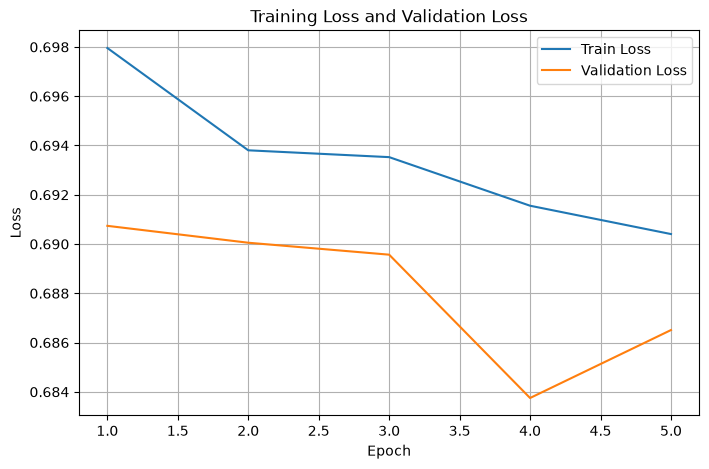

In [17]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

Testing

In [18]:
model.load_state_dict(best_model_state)

test_model(model, test_data, device)

Instance: 1-Insertions_6
  N=607, n_pos=16
  score std=0.0001
  pos mean=-0.1192
  neg mean=-0.1194
  gap pos-neg=0.0001
Instance: 3-Insertions_3
  N=56, n_pos=23
  score std=0.0009
  pos mean=0.1756
  neg mean=0.1747
  gap pos-neg=0.0009
Instance: 3-Insertions_4
  N=281, n_pos=16
  score std=0.0001
  pos mean=-0.0825
  neg mean=-0.0826
  gap pos-neg=0.0001


Save model

In [20]:
save_dir = Path('./models')
model_path = save_dir / "sort_vertices.pt"
torch.save(model.state_dict(), model_path)

Exporting model in ONNNX

In [21]:
from torch.export import Dim
model.eval()
dummy_input = torch.rand(1, 3, input_dim, dtype=torch.float32, device=device)  # [T, V, F]
dummy_edge_index = torch.tensor(
    [[0, 1, 2, 1],
     [1, 0, 1, 2]],
    dtype=torch.long,
    device=device
)

torch.onnx.export(
    model=model,
    args=(dummy_input, dummy_edge_index),
    f="./models/sort_vertices.onnx",
    input_names=["input_graph", "edge_index"],
    output_names=["output_graph"],
    dynamic_shapes=(
        {0: Dim("time_steps", min=1), 1: Dim("num_vertices", min=1)}, # input_graph [T, V, F]
        {1: Dim("num_edges", min=1)}, # edge_index [2, E]
    ),
    dynamo=True
)

[torch.onnx] Obtain model graph for `GIN_2Layers([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GIN_2Layers([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


c:\miniconda3\envs\torch3060\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.12.1+cu130',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input_graph"<FLOAT,[1,num_vertices,7]>,
                %"edge_index"<INT64,[2,num_edges]>
            ),
            outputs=(
                %"output_graph"<FLOAT,[num_vertices,1]>
            ),
            initializers=(
                %"conv1.mlp.0.weight"<FLOAT,[64,7]>{TorchTensor(...)},
                %"conv1.mlp.0.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"conv1.mlp.2.weight"<FLOAT,[64,64]>{TorchTensor(...)},
                %"conv1.mlp.2.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"conv1.norm.weight"<FLOAT,[64]>{TorchTensor(...)},
                %"conv1.norm.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"conv2.mlp.0.weig